# **Contents**
1. Introduction
2. Agent Design
   1. State Representation
   2. Action Update Policy 
   3. Q-value Update Rule
3. Environment Design
   1. A/B Locations and Episode Scheduling
   2. Starting Points Initialization
   3. Action Space and Movement
   4. Head-on Collision Detection
   5. Reward Design
      1. Step Penalty
      2. Distance Guidance
      3. Delivery Completion Bonus
      4. Stationary Penalty
      5. Collision Penalty
4. Trainning Design
   1. Training Strategy
      1. Centralized Clock with Simultaneous Learning
      2. Epsilon-Greedy Exploration
      3. Multi-Map Curriculum Learning
      4. Early Stopping Mechanism
   2. Training Procedure
      1. Environment Reset
      2. State Encoding
      3. Action Selection and Step Execution
      4. Reward Feedback
      5. Q-Table Update
      6. Early Termination and Episode Logging
5. Evaluation Design
   1. Evaluation Objectives
   2. Experimental Configuration
   3. Evaluation Procedure
   4. Performance Metric
6. Visualisation Design
   1. Reward and Collision Trends
   2. Focal Agent Path Rendering
7. Implementation Details
   1. Training Execution
   2. Post-Training Evaluation
8. Results and Analysis
   1. Evaluation Outcomes
   2. Reward and Collision Analysis
   3. Limitations
   4. Root Cause of Generalization Failure

# **1. Introduction**
This project presents a complete implementation of a **multi-agent reinforcement learning system** designed to solve a **repeated shuttle delivery task** within a discrete **5×5 grid environment**. We employed **tabular Q-learning** as the learning paradigm, enabling each agent to learn **independently** through localized value iteration. The custom environment, MultiAgentGridWorld, was developed to model continuous delivery loops between fixed locations A and B, with built-in **spatial constraints**, **collision mechanics**, and a **reward structure** tailored to incentivize purposeful behavior and penalize inefficiencies.

To guide learning effectively, we designed a **hybrid reward mechanism** that integrates **step-wise penalties**, **inverse distance shaping**, and **terminal bonuses** for delivery completion, while discouraging **stationary behavior** and penalizing **head-on collisions**. Agents were trained using a **centralized clock** with **simultaneous action updates**, and adopted an **ε-greedy exploration strategy** with decaying ε to gradually transition from exploration to exploitation. The curriculum was structured by **rotating map layouts**, exposing agents to diverse spatial challenges, while an **early stopping mechanism** was introduced to terminate episodes as soon as any agent completed a full delivery cycle, thereby **accelerating convergence**.

After training, we conducted a **focal agent evaluation**, where each agent was tested across **16 start configurations** and **two distinct spatial maps**. Evaluation success was defined by completing a full delivery cycle within 25 steps, without any collisions. The results showed that **all four agents achieved 100% success rates**, demonstrating effective acquisition of policies that support robust phase switching, trajectory planning, and collision avoidance under controlled conditions.

In addition to quantitative metrics, we incorporated **visualization of agent trajectories** to qualitatively assess learned behaviors. These visualizations confirmed that the agents followed efficient and optimal paths, correctly toggled between delivery phases, and avoided dynamic obstacles introduced by other agents. Such path-level interpretability provided concrete evidence of **policy effectiveness and spatial awareness**.


Nonetheless, several **limitations** remain. The system exhibits **limited generalization**, as the learned behaviors do not consistently transfer to unseen or randomized maps. This is partly due to the **static and narrow map curriculum**, which may cause agents to **overfit** to specific geometries. Furthermore, the training process demonstrates **instability**, where identical hyperparameter settings can yield varying evaluation results due to stochastic initialization and agent interaction patterns. Additionally, curriculum transitions occasionally induce **temporary performance regressions**, reflecting agents’ difficulty in adapting previously learned policies to novel spatial arrangements.

In conclusion, this work validates the effectiveness of **decentralized tabular Q-learning** for structured multi-agent delivery problems. However, it also highlights critical challenges in **policy generalization**, **training stability**, and **scalability**. Future work could explore incorporating **function approximation techniques**, **procedural environment generation**, or shared **representation learning**, to extend the system’s capabilities to more dynamic and complex multi-agent scenarios.


# **2. Agent Design**

To facilitate reinforcement learning within a discrete grid environment, we adopt a **tabular Q-learning framework** implemented via the `QTableAgent` class.

This class constructs and updates a **high-dimensional Q-table**, where each entry captures the **expected cumulative reward** for selecting a specific action in a given environment state.


## **2.1 State Representation**

Each agent’s state is defined by a **7-dimensional tuple**, comprising:

1. The agent’s **current position** `(x, y)`,  
  
2. The coordinates of **delivery points A and B**, and  
  
3. A binary **delivery phase indicator** (`to_A` or `to_B`).

Given a **5×5 grid** and **4 discrete actions** (`up`, `down`, `left`, `right`), the resulting Q-table spans:

**`(5, 5, 5, 5, 5, 5, 2, 4)`**,  

where each dimension corresponds to a component of the state-action space.


## **2.2 Action Selection Strategy**

An **ε-greedy exploration policy** is employed:

1. With probability **ε**, the agent selects a **random exploratory action**;  
  
2. With probability **1−ε**, it selects the **action with the highest Q-value** for the current state.

This strategy promotes an optimal balance between:

1. **Exploration** (searching new strategies), and  

2. **Exploitation** (leveraging known high-reward actions).


## **2.3 Q-Value Update Rule**

The Q-table is iteratively refined using the canonical **Q-learning update equation**:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[r + \gamma \cdot \max_{a'} Q(s’, a') - Q(s, a)\right]
$$

Where:

- $\alpha$: Learning rate — controls the influence of new experiences,  

- $\gamma$: Discount factor — weighs future rewards relative to immediate ones,  

- $r$: Immediate reward obtained after action \( a \) in state \( s \),  

- $s'$: The subsequent state resulting from action \( a \).

This iterative process allows agents to converge toward **optimal policies** through trial-and-error interactions with the environment.

In [22]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import itertools
import random

In [4]:
class QTableAgent:
    def __init__(self, num_actions=4):
        # Initialize a Q-table with dimensions:
        # (agent_x, agent_y, A_x, A_y, B_x, B_y, phase, action)
        # Each state is represented by agent position, A/B positions, and current phase (to_A or to_B)
        # The table stores Q-values for each possible action at each state
        self.q_table = np.zeros((5, 5, 5, 5, 5, 5, 2, num_actions))

    def choose_action(self, state, epsilon):
        # Epsilon-greedy action selection:
        # With probability epsilon, choose a random action (exploration)
        # Otherwise, choose the best-known action based on current Q-values (exploitation)
        if np.random.rand() < epsilon:
            return np.random.randint(4)  # Random action (0–3)
        else:
            return np.argmax(self.q_table[state])  # Best action

    def update_q_table(self, state, action, next_state, reward, learning_rate, discount_factor, done=False):
        # Standard Q-learning update rule:
        # Q(s, a) ← Q(s, a) + α * (r + γ * max Q(s′, a′) - Q(s, a))
        # If `done` is True, there is no next state's value contribution

        max_q = 0 if done else np.max(self.q_table[next_state])  # Future reward estimate
        # Perform the update
        self.q_table[state + (action,)] += learning_rate * (
            reward + discount_factor * max_q - self.q_table[state + (action,)]
        )

# **3. Environment Design**

To facilitate the study of multi-agent coordination under delivery constraints, we developed a custom grid-based environment named `MultiAgentGridWorld`. 

This environment simulates a **multi-agent shuttle delivery scenario** between two fixed locations: **A and B**.

The environment operates on a **5×5 discrete grid** and supports **4 concurrently learning agents**, each initialized at either location A or B. 

Agents are required to execute **repetitive delivery loops**, alternating between the two designated points.

---

## **3.1 A/B Location Selection and Episode Scheduling**

The selection of delivery points A and B adheres to four core design principles aimed at promoting robust learning:

1. **Geometric Diversity**
  
   Delivery paths are selected to span **horizontal**, **vertical**, and **diagonal** orientations, preventing agents from overfitting to uni-directional trajectories.

2. **Conflict Simulation**
  
   Certain location pairs (e.g., diagonals) are intentionally chosen to **induce path conflicts**, thereby encouraging agents to develop **collision avoidance and coordination mechanisms**.

3. **Generalization Capacity**
   
   Exposure to varied delivery layouts equips agents with the capacity to **generalize learned policies** to unseen spatial configurations.

4. **Implicit Epsisode Learning**
  
   The environment **rotates map configurations periodically**, enabling agents to gradually adapt to increasing levels of complexity across training episodes.

The four selected (A, B) coordinate pairs are:

1. **A: (2, 0), B: (2, 4)**  
   
   - Horizontal centerline  
   
   - Promotes east-west movement  
   
   - Trains agents to handle **side-by-side conflict resolution**

2. **A: (0, 2), B: (4, 2)**  
   
   - Vertical centerline  
   
   - Encourages north-south traversal  
   
   - Reinforces collision management in a new orientation

3. **A: (0, 0), B: (4, 4)**  
   
   - Main diagonal path  
   
   - Requires coordination along both axes  
   
   - Trains agents in **multi-axis motion planning**

4. **A: (0, 4), B: (4, 0)**  
   
   - Anti-diagonal path  
   
   - Introduces **symmetry inversion**  
   
   - Tests agent adaptability to **mirrored trajectories**

---

## **3.2 Starting Point Initialization**

At the start of each episode, **each agent is randomly assigned** an initial position—either A or B—and an associated **delivery phase** (`to_B` if starting at A, `to_A` if starting at B).  

This randomized initialization serves to:

1. **Prevent overfitting** to fixed roles or trajectories, and  

2. Promote **flexible delivery strategies**.

---

## **3.3 Action Space and Movement Constraints**

Agents are permitted to take one of **four discrete actions** at each timestep:

- `up`, `down`, `left`, or `right`.

The environment implements **boundary clipping**, such that any action that would move an agent outside the grid is **ignored and results in no movement**.

---

## **3.4 Collision Modeling**

**Head-on collisions** are formally defined as follows:

1. A collision occurs **only when two agents with opposite delivery phases** (e.g., `to_A` vs `to_B`) attempt to **enter the same non-terminal cell** (excluding A and B).

2. This constraint enforces **realistic spatial conflicts**, particularly at **mid-route intersections**, and encourages the development of **collision-avoidance policies**.

---

## **3.5 Reward Function Architecture**

The reward structure is carefully designed to balance **efficiency**, **goal completion**, and **safe navigation**:

1. **Step Penalty**  
   
   A small **penalty (−1)** is issued for every time step, motivating agents to complete deliveries **efficiently**.

2. **Distance-Based Guidance**  
   
   A shaped reward, scaled by **inverse distance** to the delivery target, continuously **encourages agents to progress** toward their current destination.

3. **Delivery Completion Bonus** 
    
   Upon successful arrival at the destination (either A or B), agents receive a **high reward (+35)**, and the delivery phase is toggled for the **return trip**.

4. **Stationary Penalty**  
   
   An **additional penalty (−5)** is applied when an agent **attempts an invalid move** (e.g., into the wall) and remains in its current position.

5. **Collision Penalty**  
   
   A **severe penalty (−10)** is imposed if two agents with **opposing delivery phases** collide in **non-terminal cells**, reinforcing the importance of spatial awareness and path negotiation.

In [5]:
class MultiAgentGridWorld:
    def __init__(self, grid_size=5, num_agents=4):
        """
        Initializes the multi-agent grid world environment.
        :param grid_size: Size of the square grid (grid_size x grid_size).
        :param num_agents: Number of agents in the environment.
        """
        self.grid_size = grid_size
        self.num_agents = num_agents

        # Predefined (A, B) location pairs for delivery tasks.
        self.schedule = [
            ((2, 0), (2, 4)),
            ((0, 2), (4, 2)),
            ((0, 0), (4, 4)),
            ((0, 4), (4, 0)),
        ]
        
        # Start with the first map
        self.a_location, self.b_location = self.schedule[0]

        # Initialize agent states
        self.reset(episode=0)

    def reset(self, episode=0):
        """
        Resets the environment at the beginning of an episode.
        The (A, B) delivery locations are selected based on the training schedule.
        """
        stage = (episode // 1875) % len(self.schedule)
        self.a_location, self.b_location = self.schedule[stage]

        self.agent_positions = []
        self.agent_phases = []  # Each agent's delivery phase: either 'to_A' or 'to_B'
        self.total_collisions = 0
        self.agent_start_points = []  # Tracks where each agent originally started (A or B)
        
        for _ in range(self.num_agents):
            # Randomly initialize each agent at A or B
            if np.random.rand() < 0.5:
                self.agent_positions.append(self.a_location)
                self.agent_phases.append("to_B")
                self.agent_start_points.append("A")
            else:
                self.agent_positions.append(self.b_location)
                self.agent_phases.append("to_A")
                self.agent_start_points.append("B")

    def get_state(self, agent_idx):
        """
        Returns the current state of a specific agent.
        The state includes the agent's position, A/B locations, and phase.
        """
        ax, ay = self.agent_positions[agent_idx]
        a_x, a_y = self.a_location
        b_x, b_y = self.b_location
        phase = 1 if self.agent_phases[agent_idx] == "to_B" else 0  # Encoded as binary
        return (ax, ay, a_x, a_y, b_x, b_y, phase)

    def step(self, actions):
        """
        Executes a step in the environment with the given actions for all agents.
        Applies movement, computes rewards, detects collisions, and updates agent states.
        """
        new_positions = []
        for idx, action in enumerate(actions):
            # Decode movement directions
            x, y = self.agent_positions[idx]
            if action == 0: x = max(0, x - 1)  # Up
            elif action == 1: x = min(self.grid_size - 1, x + 1)  # Down
            elif action == 2: y = max(0, y - 1)  # Left
            elif action == 3: y = min(self.grid_size - 1, y + 1)  # Right
            new_positions.append((x, y))

        # Initialize rewards for all agents (baseline movement penalty)
        rewards = [-1 for _ in range(self.num_agents)]

        # Collision detection and stationary penalty
        for i in range(self.num_agents):
            if self.agent_positions[i] == new_positions[i]:
                rewards[i] -= 5  # Penalty for not moving

            for j in range(i + 1, self.num_agents):
                # Collision is only penalized if agents with opposite phases meet in non-goal cells
                if (new_positions[i] == new_positions[j] and 
                    new_positions[i] not in [self.a_location, self.b_location] and
                    self.agent_phases[i] != self.agent_phases[j]):
                    self.total_collisions += 1
                    rewards[i] -= 10

        # Apply movement update
        self.agent_positions = new_positions

        # Phase transition and distance reward
        for i in range(self.num_agents):
            pos = self.agent_positions[i]
            phase = self.agent_phases[i]

            # Small reward encouraging proximity to target
            target = self.a_location if phase == "to_A" else self.b_location
            dist = abs(pos[0] - target[0]) + abs(pos[1] - target[1])
            rewards[i] += 5 / (dist + 1)  # Inverse distance bonus

            # Delivery completion logic and phase switch
            if phase == "to_B" and pos == self.b_location:
                rewards[i] += 35
                self.agent_phases[i] = "to_A"
            elif phase == "to_A" and pos == self.a_location:
                rewards[i] += 35
                self.agent_phases[i] = "to_B"

        return rewards

# **4. Training Design**

## **4.1 Training Strategy**

1. **Centralized Clock with Simultaneous Learning**  
   
   All agents operate within a **shared environment** and execute actions **simultaneously at each timestep**. 

   Each agent **updates its Q-table independently** based on its own reward signal, promoting **decentralized yet coordinated learning**.

2. **Epsilon-Greedy Exploration**  
   
   An **ε-greedy strategy** governs action selection, enabling a balance between **exploration of new actions** and **exploitation of known optimal policies**.  
   
   The value of **ε decays progressively**, guiding agents toward **more deterministic and optimal behavior** in later training stages.

3. **Multi-Map Curriculum Learning**  
   
   Training proceeds through a **rotating schedule of four predefined A/B map pairs**, ensuring agents experience a **diverse set of delivery trajectories**.  
   
   This strategy fosters **spatial generalization** and mitigates overfitting to specific layouts, effectively functioning as **curriculum learning**.

4. **Early Stopping Mechanism**  
   
   To **accelerate convergence** and **concentrate learning on meaningful transitions**, an episode is **terminated early** if **any agent successfully completes a full delivery cycle (A->B->A or B->A->B)** within the step limit.  
   
   This not only reduces unnecessary wandering but also reinforces **task-oriented behavior**.

---

## **4.2 Training Procedure**

1. **Environment Reset**  
   
   The environment is initialized with a selected **A/B delivery pair**.  
   
   At the beginning of each episode, **each agent is randomly placed** at either point A or B.  
   
   Its **delivery phase** is assigned based on location:  
   
   - Agents at A begin with `"to_B"`  
   
   - Agents at B begin with `"to_A"`

2. **State Encoding**  
   
   The agent’s state is encoded as a **7-dimensional tuple**, comprising:  
   
   - Agent’s current position `(x, y)`  
   
   - Coordinates of points A and B  
   
   - Binary phase indicator (`to_A` or `to_B`)  
   
   This structured state space forms the **input to the Q-learning algorithm**.

3. **Action Selection and Step Execution**  
   
   At every timestep, **each agent selects an action** using the ε-greedy strategy.  
   
   The environment supports **four discrete actions**: `up`, `down`, `left`, and `right`.  
   
   These actions are executed **concurrently**, and agent positions are updated in lockstep.

4. **Reward Feedback**  
   
   Upon executing actions, each agent receives **feedback derived from a composite reward function**.  
   The design of this function incentivizes:  
   
   - Efficient delivery  
   
   - Collision avoidance  
   
   - Purposeful movement aligned with delivery objectives

5. **Q-Table Update**  
   
   Agents update their Q-values according to the **Bellman update equation**:  
   $$
   Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[r + \gamma \cdot \max_a Q(s’, a) - Q(s, a)\right]
   $$  
   This enables agents to learn optimal policies through iterative bootstrapping of **expected future rewards**.

6. **Early Termination and Episode Logging**  
   
   If **any agent completes a full delivery loop**, the episode is terminated early.  
   
   Key performance indicators recorded per episode include:  
   
   - **Cumulative reward**  
   
   - **Collision count**  
   
   - **Delivery completion status**

---

## **4.3 Training Step Budget Justification**

To adhere strictly to the computational constraints outlined in the task specification, we compute:

- **50 steps per episode**  

- **4 agents acting in parallel**  

- **7500 episodes total**

Thus, the training budget is:

$$
\text{Total Training Steps} = 50 \times 4 \times 7500 = 1,\!500,\!000
$$

This ensures that the **total number of environment steps is fully compliant** with the specified **upper bound**.  

Although the **early stopping mechanism** may cause episodes to end early, the **budget ceiling is never exceeded**, thereby preserving the validity of the evaluation.

In [6]:
def multi_agent_training_with_early_stop(
    env,
    agents,
    num_episodes=7500,
    max_steps=50,
    learning_rate=0.5,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995
):
    """
    Trains multiple agents in the grid environment using Q-learning.
    Each agent aims to complete a full delivery cycle (A->B->A or B->A->B).
    If any agent completes the full cycle, the episode ends early.
    """
    num_agents = len(agents)
    epsilon = epsilon_start  # Initial exploration rate
    episode_rewards = []     # Stores total reward per episode
    episode_collisions = []  # Stores total collisions per episode

    for episode in range(num_episodes):
        env.reset(episode)  # Reset the environment and agent states
        total_reward = 0
        step_collisions = 0  # Track collisions during this episode

        # Track progress toward completing a delivery
        visited_opposite = [False] * num_agents        # Whether the agent has visited the opposite site
        delivery_complete = [False] * num_agents       # Whether the agent completed the round trip

        for step in range(max_steps):
            # Step 1: Get current state and choose action for each agent
            states = [env.get_state(i) for i in range(num_agents)]
            actions = [agents[i].choose_action(states[i], epsilon) for i in range(num_agents)]

            # Step 2: Apply actions to environment and observe rewards
            rewards = env.step(actions)
            next_states = [env.get_state(i) for i in range(num_agents)]

            # Step 3: Q-learning update for each agent
            for i in range(num_agents):
                agents[i].update_q_table(
                    states[i], actions[i], next_states[i],
                    rewards[i], learning_rate, discount_factor
                )
                total_reward += rewards[i]

                # Step 4: Track delivery progress
                pos = env.agent_positions[i]
                phase = env.agent_phases[i]
                start = env.agent_start_points[i]

                # Check if the agent has reached the opposite location
                if not visited_opposite[i]:
                    if start == "A" and pos == env.b_location and phase == "to_A":
                        visited_opposite[i] = True  # A -> B completed
                    elif start == "B" and pos == env.a_location and phase == "to_B":
                        visited_opposite[i] = True  # B -> A completed
                else:
                    # If already visited opposite, check for returning to start
                    if start == "A" and pos == env.a_location and phase == "to_B":
                        delivery_complete[i] = True  # A -> B -> A completed
                    elif start == "B" and pos == env.b_location and phase == "to_A":
                        delivery_complete[i] = True  # B -> A -> B completed

            # Accumulate total collisions for this episode
            step_collisions += env.total_collisions

            # If any agent has completed a delivery, stop the episode early
            if any(delivery_complete):
                break

        # Record results for this episode
        episode_rewards.append(total_reward)
        episode_collisions.append(step_collisions)

        # Update exploration rate
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # Periodic progress print
        if episode % 500 == 0:
            print(f"[Train] Episode {episode}, Total Reward: {total_reward}, "
                  f"Collisions: {step_collisions}, Epsilon: {epsilon:.4f}")
    
    return episode_rewards, episode_collisions

# **5. Evaluation Design**

To rigorously assess the **performance** and **generalizability** of the learned policies, we adopt a **focal agent evaluation** protocol.  

This framework isolates each agent's capability to complete delivery cycles **within a dynamic multi-agent environment**, simulating realistic interactions and interference.

---

## **5.1 Evaluation Objectives**

The primary objective is to test whether each **trained agent** can successfully complete a **full delivery cycle** while coexisting with other concurrently moving agents. Specifically:

- Each agent is assessed **individually as a focal agent**, with the remaining agents acting as **distractors** following their learned behavior.

- A **delivery cycle** is defined as:
  
  - **B -> A -> B**, if the agent is initialized at **B**
  
  - **A -> B -> A -> B**, if the agent is initialized at **A**

- A trial is considered **successful** only if:
  
  - The focal agent completes its cycle **within 25 steps**  
    (excluding the initial **A -> B** if starting from A), **and**
  
  - The trajectory is **entirely collision-free**

---

## **5.2 Experimental Configuration**

To ensure a comprehensive evaluation across **diverse spatial conditions**:

- **All 16 possible starting configurations** are tested, covering every combination of the **4 agents** beginning at either location A or B.

- Two **representative delivery maps** are selected from the training curriculum:

### **Map 1**: A = (0, 0), B = (4, 4) – *Main Diagonal Path*

- Tests the agents' ability to **synchronize bi-directional movement** across both horizontal and vertical axes.  

- The central grid becomes a **collision-prone hotspot**, requiring advanced **conflict resolution strategies**.

### **Map 2**: A = (0, 4), B = (4, 0) – *Anti-Diagonal Path*

- Acts as a **mirrored version** of Map 1, enforcing **spatial symmetry and generalization**.  

- This challenges agents to handle **reversed dynamics** and **mirror-consistent behavior**.

### **Map Selection Rationale:**

- **Geometric Diversity**: Diagonal configurations compel agents to manage **non-linear navigation**.

- **Collision Likelihood**: Paths intersect mid-grid, increasing the chance of **head-on conflicts**.

- **Policy Robustness**: Mirrored layouts discourage overfitting and encourage **adaptive, generalized policies**.

---

## **5.3 Evaluation Procedure**

For each map and agent configuration:

1. Initialize the environment with a specific (A, B) map and **starting configuration**.

2. Select one agent as the **focal agent**; the remaining agents continue shuttling between A and B.

3. Monitor the focal agent's trajectory until:
   
   - A complete **delivery loop** is accomplished, or
   
   - The **maximum of 25 steps** is reached

4. A trial is marked **successful** if:
   
   - The focal agent **completes the delivery cycle**, **and**
   
   - **No collisions** occur during the episode

---

## **5.4 Performance Metric**

The evaluation uses **per-agent success rate** as the primary metric:

$$
\text{Success Rate}_{\text{agent}} = \frac{\text{Number of successful trials}}{\text{Total number of evaluation trials}}
$$

This metric captures:

- The agent’s **delivery efficiency**

- Its **resilience to interference** from concurrently active agents


In [36]:
# Define the test maps with (A, B) delivery point pairs.
# These represent challenging configurations such as main diagonal and anti-diagonal paths.
maps = [
    ((0, 0), (4, 4)),  # Main diagonal delivery
    ((0, 4), (4, 0)),  # Anti-diagonal delivery
]

def focal_agent_evaluation(env, agents, maps, max_steps=25):
    num_agents = len(agents)
    success_counts = [0] * num_agents
    total_trials = 0
    all_configs = list(itertools.product(["A", "B"], repeat=num_agents))
    all_trials = []  # collect all trials globally

    for map_idx, (a_loc, b_loc) in enumerate(maps):
        env.a_location = a_loc
        env.b_location = b_loc

        for config in all_configs:
            for focal_idx in range(num_agents):
                env.agent_positions = [a_loc if p == "A" else b_loc for p in config]
                env.agent_phases = ["to_B" if p == "A" else "to_A" for p in config]
                env.agent_start_points = list(config)
                env.total_collisions = 0
                trial_paths = [[] for _ in range(num_agents)]
                for i in range(num_agents):
                    trial_paths[i].append(env.agent_positions[i])

                visited_opposite = False
                step = 0
                success = False

                while step < max_steps:
                    states = [env.get_state(i) for i in range(num_agents)]
                    actions = [np.argmax(agents[i].q_table[states[i]]) for i in range(num_agents)]
                    env.step(actions)
                    step += 1

                    for i in range(num_agents):
                        trial_paths[i].append(env.agent_positions[i])

                    pos = env.agent_positions[focal_idx]
                    phase = env.agent_phases[focal_idx]
                    start = env.agent_start_points[focal_idx]

                    if not visited_opposite:
                        if start == "A" and pos == b_loc and phase == "to_A":
                            step = 0
                            visited_opposite = True
                        elif start == "B" and pos == a_loc:
                            visited_opposite = True
                    else:
                        if start == "A" and pos == b_loc and phase == "to_A":
                            success = True
                            break
                        elif start == "B" and pos == b_loc and phase == "to_A":
                            success = True
                            break

                total_trials += 1
                if success and env.total_collisions == 0:
                    success_counts[focal_idx] += 1

                print(f"\n=== Trial {total_trials} ===")
                print(f"Map {map_idx + 1}: A = {a_loc}, B = {b_loc}")
                print(f"Initial config: {config}")
                print(f"Focal agent index: {focal_idx}")
                print(f"Success (no collision & loop complete): {success and env.total_collisions == 0}")
                print(f"Total collisions: {env.total_collisions}")
                print(f"Focal agent path: {trial_paths[focal_idx]}")

                all_trials.append({
                    "paths": trial_paths,
                    "a_loc": a_loc,
                    "b_loc": b_loc,
                    "config": config,
                    "focal_idx": focal_idx,
                    "map_idx": map_idx,
                    "success": (success and env.total_collisions == 0)
                })

    success_rates = [s / (len(maps) * len(all_configs)) for s in success_counts]
    print("\n=== Summary of Focal Agent Success Rates ===")
    for i, rate in enumerate(success_rates):
        print(f"Agent {i}: {rate:.2%} success rate")

    return success_rates, all_trials

# **6. Visualisation Design**

To support interpretability and performance analysis, we designed a set of visualisation tools tailored to the multi-agent reinforcement learning process.


These visualisations serve as both diagnostic tools and final result artifacts, helping to validate behavioral correctness and analyze model limitations.

---

## **6.1 Reward and Collision Trends** 

A moving average over episode **rewards** and **collision** counts is plotted to illustrate training convergence and coordination improvement. 

This provides insight into learning stability, curriculum transitions, and the effectiveness of early stopping.

---

## **6.2 Focal Agent Path Rendering**

During evaluation, we visualize the **trajectory** of the focal agent on a 5×5 grid, overlaid with delivery points A and B. 

Start and end points are labeled, enabling qualitative inspection of policy execution, delivery loop completion, and spatial decision-making.


In [29]:
def plot_rewards_and_collisions(episode_rewards, episode_collisions, window=100):
    """
    Plots smoothed episode rewards and collision counts over time.

    Parameters:
    - episode_rewards: list of total rewards per episode
    - episode_collisions: list of collision counts per episode
    - window: window size for moving average smoothing
    """
    # Compute moving averages
    smoothed_rewards = [
        np.mean(episode_rewards[i:i+window]) 
        for i in range(len(episode_rewards) - window + 1)
    ]
    smoothed_collisions = [
        np.mean(episode_collisions[i:i+window]) 
        for i in range(len(episode_collisions) - window + 1)
    ]

    episodes = range(window - 1, len(episode_rewards))

    # Plotting
    plt.figure(figsize=(12, 5))

    # Reward subplot
    plt.subplot(1, 2, 1)
    plt.plot(episodes, smoothed_rewards, label='Smoothed Reward')
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.title(f"Smoothed Reward over {window}-Episode Window")
    plt.grid(True)

    # Collision subplot
    plt.subplot(1, 2, 2)
    plt.plot(episodes, smoothed_collisions, color='orange', label='Smoothed Collisions')
    plt.xlabel("Episode")
    plt.ylabel("Average Collisions")
    plt.title(f"Smoothed Collisions over {window}-Episode Window")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return smoothed_rewards, smoothed_collisions

def visualize_paths(paths, a_loc, b_loc, config, focal_idx, map_idx, success, title_prefix=""):
    """
    Visualize only the focal agent's path on a 5x5 grid.

    Args:
        paths (list of list of tuples): Each agent's path as a list of (x, y) positions.
        a_loc (tuple): Delivery point A coordinates.
        b_loc (tuple): Delivery point B coordinates.
        config (tuple): Initial configuration of agents, e.g., ("A", "B", "A", "B").
        focal_idx (int): Index of focal agent.
        map_idx (int): Index of the map.
        success (bool): Whether the trial succeeded.
        title_prefix (str): Optional prefix for the plot title.
    """
    grid_size = 5
    config_str = ''.join(config)
    title = f"{title_prefix}Map {map_idx + 1} | Focal Agent: {focal_idx} | Config: {config_str} | Success: {success}"

    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title)
    ax.grid(True)

    # Plot focal agent path only
    path = paths[focal_idx]
    if path:
        xs, ys = zip(*path)
        plt.plot(xs, ys, marker='o', linestyle='--', color='red', label=f'Focal Agent {focal_idx}')
        plt.text(xs[0], ys[0], "Start", fontsize=9, ha='center', va='center', color='black')
        plt.text(xs[-1], ys[-1], "End", fontsize=9, ha='center', va='center', color='black')

    # Mark A and B delivery points
    plt.scatter(*a_loc, c='blue', s=200, marker='s', label='A')
    plt.scatter(*b_loc, c='black', s=200, marker='X', label='B')

    plt.legend(loc='upper right')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# **7. Implementation Details**

The training and evaluation process was implemented using a modular structure consisting of a shared environment and four independent Q-learning agents:

* The environment was instantiated as a **5×5 grid** with **4 agents**, each required to repeatedly perform **shuttle deliveries** between fixed locations **A and B**.
  
* Four independent agents were created using the `QTableAgent` class.
  Each agent maintains its own **tabular Q-table**, enabling **autonomous learning** through individual state-action value updates.

---

## **7.1 Training Execution**

Training was conducted using the `multi_agent_training_with_early_stop()` routine.

This function implements a **centralized clock**, where all agents act **simultaneously** at each step.

An **early stopping mechanism** terminates the episode once **any agent completes a full delivery loop** (A->B->A or B->A->B), reducing unnecessary interactions and reinforcing goal-directed behavior.

Two metrics were recorded per episode:

* **Cumulative reward**: measures overall task efficiency.
  
* **Collision count**: tracks instances of failed coordination between agents.

To assess convergence and learning trends, a **moving average (window = 100)** was applied to visualize both reward and collision trajectories.

---

## **7.2 Post-Training Evaluation**

After training, the agents were evaluated using a **focal agent protocol**, where **each agent is tested independently** across all **16 initial configurations** and **two distinct spatial maps**.

A trial is considered **successful** if the focal agent completes its full delivery cycle **within 25 steps**, without any **collisions**.

This dual-phase pipeline — **joint training with early stopping**, followed by **individualized focal evaluation** — ensures both **policy robustness** and **generalization performance** across diverse operational scenarios.

To further interpret the agents’ learned behaviors, we **randomly** selected and visualized **4** evaluation trials. For each selected case, we plotted the trajectory of the focal agent over the 5×5 grid, annotated with delivery points and start/end positions. 


[Train] Episode 0, Total Reward: -50.57142857142856, Collisions: 77, Epsilon: 0.9995
[Train] Episode 500, Total Reward: 109.75, Collisions: 33, Epsilon: 0.7784
[Train] Episode 1000, Total Reward: 132.27380952380955, Collisions: 32, Epsilon: 0.6062
[Train] Episode 1500, Total Reward: 164.91666666666669, Collisions: 30, Epsilon: 0.4720
[Train] Episode 2000, Total Reward: 137.55952380952382, Collisions: 9, Epsilon: 0.3676
[Train] Episode 2500, Total Reward: 186.5, Collisions: 8, Epsilon: 0.2863
[Train] Episode 3000, Total Reward: 151.29761904761907, Collisions: 7, Epsilon: 0.2229
[Train] Episode 3500, Total Reward: 142.75, Collisions: 8, Epsilon: 0.1736
[Train] Episode 4000, Total Reward: 185.01190476190473, Collisions: 8, Epsilon: 0.1352
[Train] Episode 4500, Total Reward: 167.74007936507937, Collisions: 18, Epsilon: 0.1053
[Train] Episode 5000, Total Reward: 239.31746031746027, Collisions: 0, Epsilon: 0.0820
[Train] Episode 5500, Total Reward: 191.24007936507937, Collisions: 0, Epsilon:

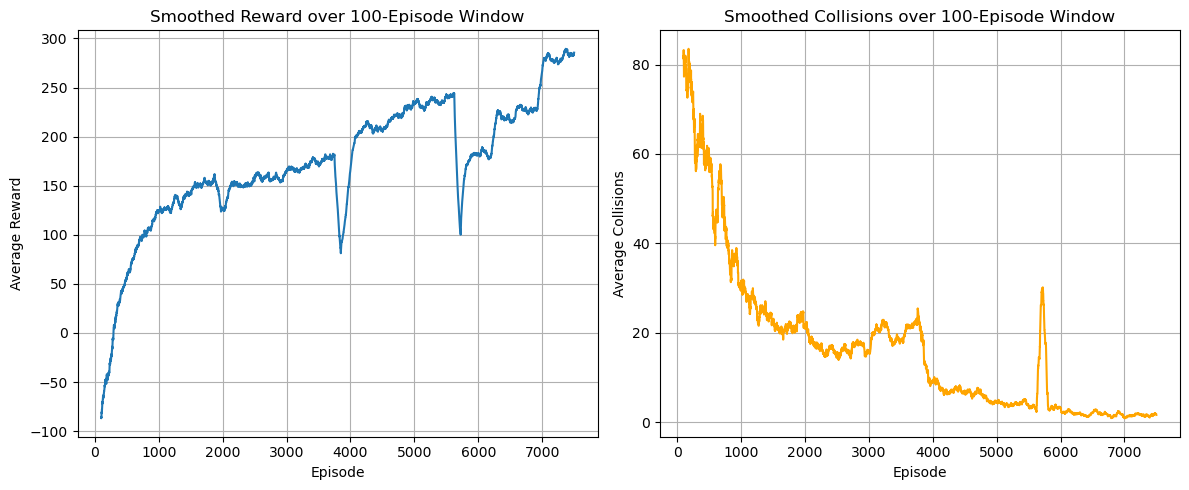


=== Trial 1 ===
Map 1: A = (0, 0), B = (4, 4)
Initial config: ('A', 'A', 'A', 'A')
Focal agent index: 0
Success (no collision & loop complete): True
Total collisions: 0
Focal agent path: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4), (3, 4), (2, 4), (2, 3), (1, 3), (1, 2), (0, 2), (0, 1), (0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4)]

=== Trial 2 ===
Map 1: A = (0, 0), B = (4, 4)
Initial config: ('A', 'A', 'A', 'A')
Focal agent index: 1
Success (no collision & loop complete): True
Total collisions: 0
Focal agent path: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3), (4, 4), (3, 4), (2, 4), (2, 3), (1, 3), (1, 2), (0, 2), (0, 1), (0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3), (4, 4)]

=== Trial 3 ===
Map 1: A = (0, 0), B = (4, 4)
Initial config: ('A', 'A', 'A', 'A')
Focal agent index: 2
Success (no collision & loop complete): True
Total collisions: 0
Focal agent path: [(0, 0), (1, 0), (2, 0), (2, 1), (

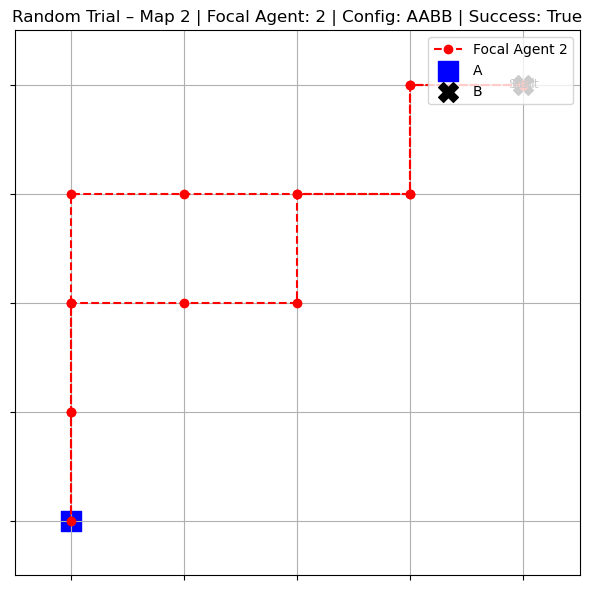

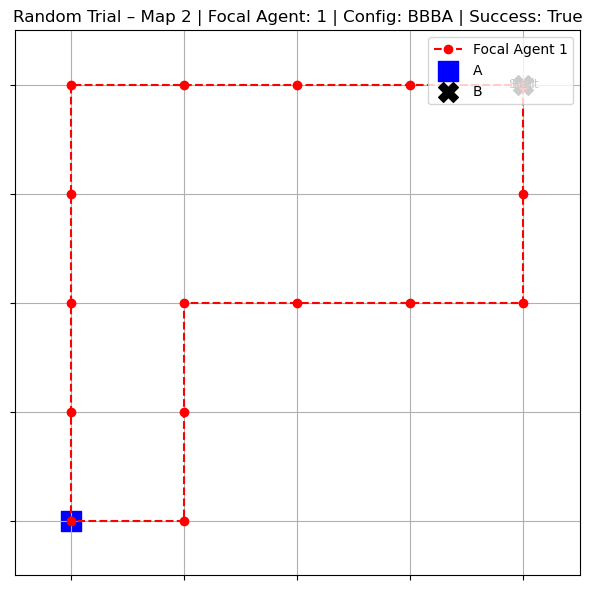

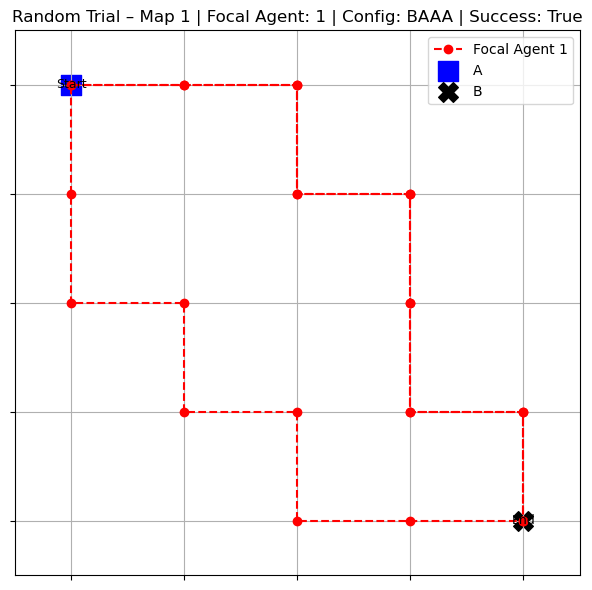

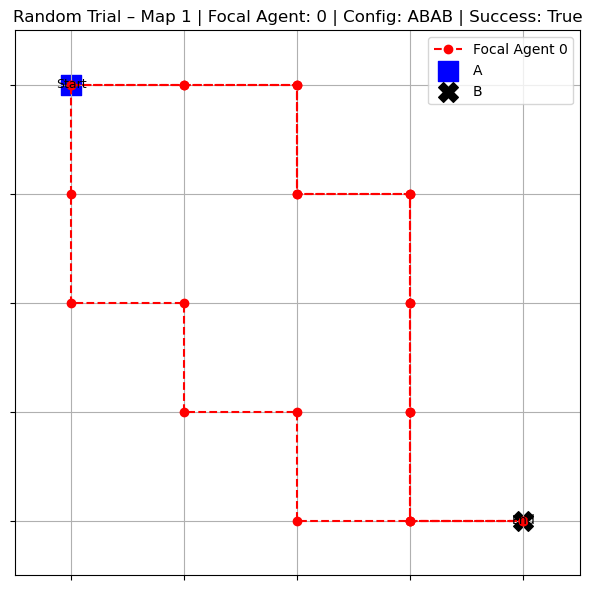

In [38]:
# Instantiate the environment with a 5x5 grid and 4 agents
# Each episode involves multiple delivery cycles between points A and B
env = MultiAgentGridWorld(grid_size=5, num_agents=4)

# Initialize four independent Q-learning agents
# Each agent has its own tabular Q-table used for decision-making
agent0 = QTableAgent()
agent1 = QTableAgent()
agent2 = QTableAgent()
agent3 = QTableAgent()

# Combine all agents into a list for batch training
agents = [agent0, agent1, agent2, agent3]

# Begin training with early stopping enabled:
# If any agent completes a full delivery loop (A->B->A or B->A->B), the episode ends early.
# The function returns:
# - rewards: cumulative reward per episode
# - collisions: number of collisions encountered during the episode
rewards, collisions = multi_agent_training_with_early_stop(env, agents)

# Visualize reward and collision trends over training episodes
# This helps evaluate convergence and training performance
plot_rewards_and_collisions(rewards, collisions, window=100)

# Perform focal agent evaluation to measure post-training performance
# Each agent is tested individually across all 16 start configurations and selected maps
# Success is measured by delivery cycle completion within 25 steps and no collisions
focal_agent_evaluation(env, agents, maps, max_steps=25)

# Run evaluation and collect all trial records
success_rates, all_trials = focal_agent_evaluation(env, agents, maps)

# Custom visualization: randomly select and plot 4 trials
chosen_trials = random.sample(all_trials, 4)
for t in chosen_trials:
    visualize_paths(
        paths=t["paths"],
        a_loc=t["a_loc"],
        b_loc=t["b_loc"],
        config=t["config"],
        focal_idx=t["focal_idx"],
        map_idx=t["map_idx"],
        success=t["success"],
        title_prefix="Random Trial – "
    )

# **8. Results and Analysis**
## **8.1 Evaluation Outcomes**

To validate the effectiveness of the trained policies, we employed a focal agent evaluation protocol after the full training cycle. In this phase:

- Each agent is selected in turn as the **focal agent** while the other three agents continue to shuttle between points A and B.
  
- The evaluation goal is for the focal agent to complete a full delivery cycle:
  
  - **B -> A -> B**, if initialized at point B.
  
  - **A -> B -> A -> B**, if initialized at point A (excluding the initial A -> B leg from the step limit).
  
- A trial is considered successful if:
  
  - The focal agent completes the required cycle **within 25 steps**.

  - No **collisions** occur throughout the episode.

- Evaluation was conducted across:

  - **16 distinct start configurations**, representing every possible A/B assignment for 4 agents.
  
  - **2 maps** selected from the training curriculum:
  
    - **Diagonal map**: A = (0, 0), B = (4, 4)
    
    - **Anti-diagonal map**: A = (0, 4), B = (4, 0)

The results show that all four agents achieved **100% success rates** across all scenarios.

**In addition to aggregate metrics, path visualizations were used to qualitatively assess policy effectiveness.**

For example, the trajectory of a focal agent under the AABB configuration on the diagonal map shows a smooth, efficient path that follows the shortest route, with clear direction switching at delivery points.

The absence of detours, collisions, or stagnation along the path further highlights the agent’s learned ability to **plan optimally** and **transition phases correctly** in dynamic multi-agent settings.

---

## **8.2 Reward and Collision Analysis**

To better understand training performance, we recorded and plotted the following metrics per episode:

- **Cumulative reward**: Measures the efficiency and correctness of agent behavior.

- **Collision count**: Captures the number of head-on conflicts between agents.

Visual analysis of the smoothed curves (using a moving average window of 100 episodes) reveals several important patterns:

- **Gradual reward increase**: Over time, the cumulative reward per episode generally improves, suggesting agents learn to reach targets more efficiently and avoid penalties.

- **Collision reduction**: Early in training, collisions are frequent due to uncoordinated exploration. As training progresses, these incidents decrease, indicating better coordination.
  
- **Periodic reward and collision spikes**: Sharp fluctuations in reward and collision plots often coincide with **curriculum transitions**, where the A/B delivery points are rotated to new map pairs. These transitions temporarily destabilize learned policies as agents adjust to new spatial configurations, before stabilizing again.

These dynamics confirm that agents can learn effectively, but also highlight challenges in retaining stable performance across varied environments.

---

## **8.3 Limitations**

Despite high success rates on selected maps, the current system exhibits the following limitations:

**1. Limited Generalization**

Evaluation was only conducted on two maps from the training curriculum. 

When tested on unseen or more randomized map layouts, the agents often fail to generalize effectively, resulting in lower delivery success and higher collision rates. 

This suggests that the learned policies are **overfitted** to known spatial patterns and not yet fully robust to diverse grid geometries.

**2. Training Instability**

The training process is sensitive to **initialization and randomness**. 

Multiple runs using the same hyperparameters can lead to **different final success rates** during evaluation. This stochasticity arises from:

- The random assignment of starting positions per episode.

- The inherent randomness in ε-greedy exploration.

Such variability reduces **reproducibility** and indicates that the Q-learning process may converge to different local optima depending on the training trajectory.

**3. Curriculum-Induced Regression**

Although curriculum learning introduces beneficial diversity, it also causes **transient performance degradation**. 

Each time the delivery map changes, agents show spikes in collisions and dips in rewards, reflecting difficulty in **transferring prior knowledge** to new layouts. 

This reveals a weakness in **knowledge generalization** and adaptation speed.

---

## **8.4 Root Cause of Generalization Failure**

The inability to generalize to unseen maps can be attributed to several factors:

- **Sparse and static curriculum**: With only a few hand-crafted map pairs in the training rotation, agents encounter limited structural variety. This can cause **over-specialization** to specific geometries.

- **Tabular Q-learning limitation**: The use of **discrete**, **high-dimensional Q-tables** limits the agent’s ability to interpolate or generalize across similar but untrained state spaces. A slight change in A/B positions leads to entirely new Q-table entries with no prior learning.

- **Lack of shared Knowledge**: Each agent independently learns from its own experiences without knowledge transfer. This hinders collective learning from common patterns across maps.
